# DTEx231D. LodeSTAR to Detect the Cells in the BF-C2DT-HSC Dataset

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/LodeSTAR/03.track_BF-C2DL-HSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack deeplay  # Uncomment if running on Colab/Kaggle

???

In [2]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Downloading the Data

???

In [3]:
import os

from torchvision.datasets.utils import _extract_zip, download_url


dataset_path = "./cell_detection_dataset/BF-C2DL-HSC"
if not os.path.exists(dataset_path):
    url = (
        "http://data.celltrackingchallenge.net/training-datasets/"
        "BF-C2DL-HSC.zip"
    )
    download_url(url, ".")
    _extract_zip("BF-C2DL-HSC.zip", dataset_path, None)
    os.remove("BF-C2DL-HSC.zip")

???

In [4]:
dir = os.path.join(dataset_path, "02")

## 2. Loading the Data

???

In [7]:
from PIL import Image


def load_tif_movie(tif_dir):
    """Loads Data."""

    tif_files = sorted(
        [
            os.path.join(tif_dir, f)
            for f in os.listdir(tif_dir)
            if f.lower().endswith(".tif")
        ]
    )
    frames = [np.array(Image.open(f)) for f in tif_files]

    movie = np.stack(frames, axis=0)

    return movie

???

In [8]:
def normalize_min_max(img, squeeze_in_2D=False):
    """Normalizes intensities."""

    if squeeze_in_2D:
        img = np.squeeze(img)

    max_intensity = np.max(img)
    min_intensity = np.min(img)

    if max_intensity == min_intensity:
        raise ValueError("Cannot normalize array with uniform intensity.")

    normalized_img = (img - min_intensity) / (max_intensity - min_intensity)

    return normalized_img

???

In [9]:
movie = load_tif_movie(dir)

movie = normalize_min_max(movie)

print(
    f"Loaded {movie.shape[0]} frames of size {movie.shape[1]}x{movie.shape[2]}"
)

Loaded 1764 frames of size 1010x1010


???

## 3. Cropping a Cell

???

In [10]:
t, x, y, w = (251, 80, 538, 40)
crop = movie[t, y : y + w, x : x + w]

???

In [13]:
print(f"Crop shape = {crop.shape}")

Crop shape = (40, 40)


???

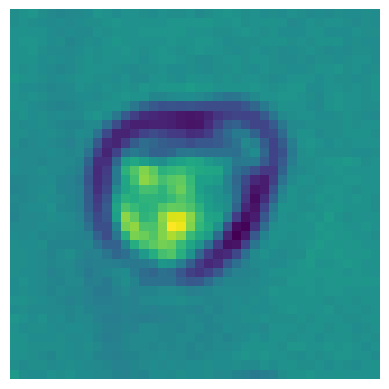

In [15]:
plt.imshow(crop)
plt.axis("off")
plt.show()

## 4. Training LodeSTAR

Instance LodeSTAR ...

In [16]:
model = dl.LodeSTAR(n_transforms=4, optimizer=dl.Adam(lr=1e-4)).build()

... define training pipeline, dataset, and dataloader ...

In [18]:
training_crop = crop[np.newaxis]  # Add empty batch dimension for compatability

training_pipeline = (
    dt.Value(training_crop)
    >> dt.Add(lambda: np.random.randn() * 0.1)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.2))
    >> dt.Multiply(lambda: np.random.uniform(0.6, 1.2))
    >> dt.NormalizeMinMax()
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)
train_dataset = dt.pytorch.Dataset(
    training_pipeline,
    length=256,
    replace=False,
)
dataloader = dl.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
)

... train it ...

In [19]:
trainer_lodestar = dl.Trainer(max_epochs=100, accelerator="auto")
trainer_lodestar.fit(model, dataloader)

/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:477: The t

Training: |          | 0/? [00:00<?, ?it/s]

... plot training history ...

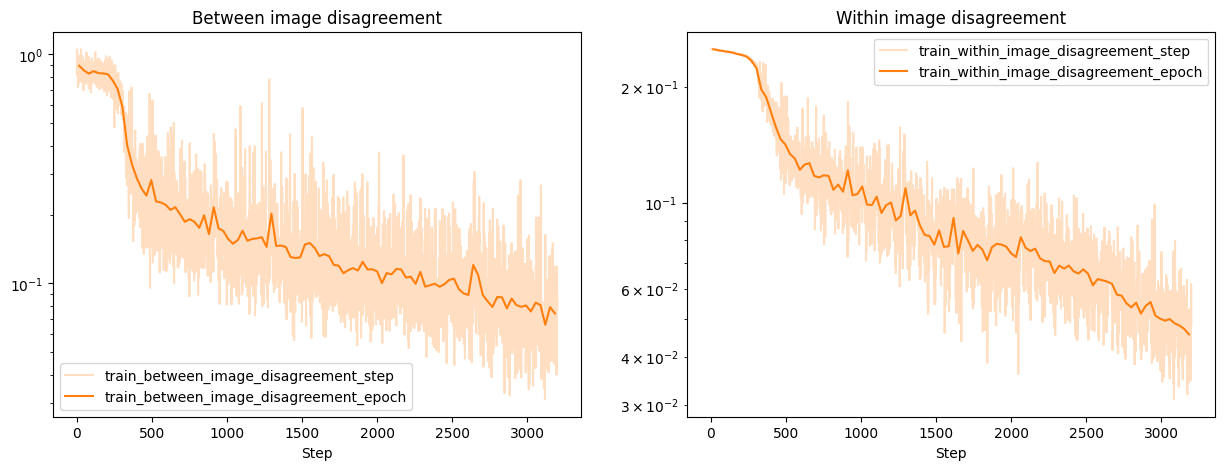

In [21]:
trainer_lodestar.history.plot();

... and save weights.

In [23]:
torch.save(model.state_dict(), f"{dir}/lodestar_weights_BF-C2DL-HSC.pth")

## 5. Testing the Model

Extract the last frame of the movie ...

In [32]:
frame_index = -1
image = normalize_min_max(movie[frame_index])

image = image[130:-130, :400]  # Crop to focus on the cells

... convert the image to tensor for LodeSTAR ...

In [33]:
image = (
    torch.as_tensor(image, dtype=torch.float32)
    .detach()
    .unsqueeze(0)
    .unsqueeze(0)
    .to(model.device)
)

... execute LodeSTAR (may need to tune the parameters to get optimal performance) ...

In [ ]:
alpha = 0.2
cutoff = 0.978

detections = model.detect(
    image, alpha=alpha, beta=1 - alpha, cutoff=cutoff, mode="quantile"
)[0]

... and plot the result.

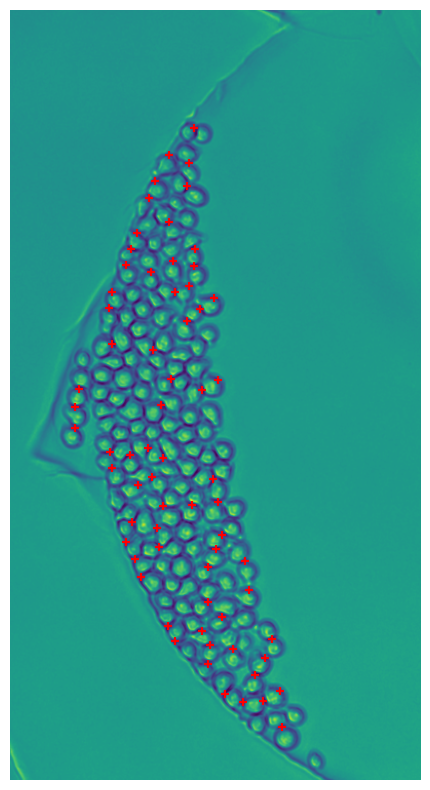

In [37]:
plt.figure(figsize=(10, 10))
plt.imshow(image.cpu()[0, 0, :, :])
plt.axis("off")
plt.scatter(detections[:, 1], detections[:, 0], color="r", marker="+")
plt.show()